# Faze 5: Trenovani a evaluace modelu

Vizualizace vysledku trenovani Decision Tree, Random Forest a XGBoost.

In [1]:
import os
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from pathlib import Path

_PROJECT_ROOT = Path(os.path.abspath("")).parent if Path(os.path.abspath("")).name == "notebooks" else Path(os.path.abspath(""))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

RESULTS_DIR = Path("results/phase5_modeling")
print(f"Pracovni adresar: {os.getcwd()}")
print(f"Slozka vysledku:  {RESULTS_DIR.resolve()}")

Pracovni adresar: C:\Users\kosar\Desktop\bakalarka_git\bakalarka
Slozka vysledku:  C:\Users\kosar\Desktop\bakalarka_git\bakalarka\results\phase5_modeling


In [2]:
comparison = pd.read_csv(RESULTS_DIR / "model_comparison_table.csv")
print(comparison.to_string(index=False))

   model  accuracy  f1_macro  f1_shelf_picking  f1_front_zone_bin  f1_special_zone  f1_floor_block  f1_pallet_rack  train_time_s  predict_time_ms
      dt    0.9807    0.9816            0.9849             0.9830           0.9562          0.9869          0.9970          6.08             5.98
      rf    0.9822    0.9814            0.9875             0.9827           0.9653          0.9813          0.9901         27.35            66.85
     xgb    0.9865    0.9866            0.9905             0.9865           0.9713          0.9897          0.9950         17.02            23.63
baseline    1.0000    1.0000            1.0000             1.0000           1.0000          1.0000          1.0000          0.00             0.00


## 1. Srovnani modelu

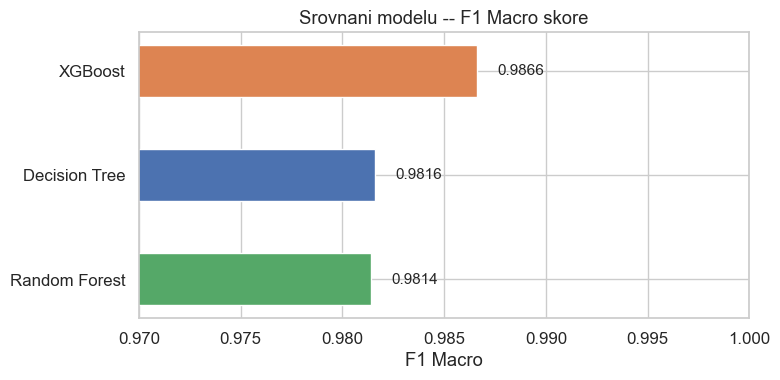

Ulozeno: results/modeling_f1_comparison.png


In [3]:
ml_models = comparison[comparison["model"] != "baseline"].copy()
ml_models = ml_models.sort_values("f1_macro", ascending=True)

color_map = {"dt": "#4C72B0", "rf": "#55A868", "xgb": "#DD8452", "baseline": "#999999"}
colors = [color_map[m] for m in ml_models["model"]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ml_models["model"].map({"dt": "Decision Tree", "rf": "Random Forest", "xgb": "XGBoost"}),
               ml_models["f1_macro"], color=colors, edgecolor="white", height=0.5)

for bar, val in zip(bars, ml_models["f1_macro"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=11)

ax.set_xlabel("F1 Macro")
ax.set_title("Srovnani modelu -- F1 Macro skore")
ax.set_xlim(0.97, 1.0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "modeling_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/modeling_f1_comparison.png")

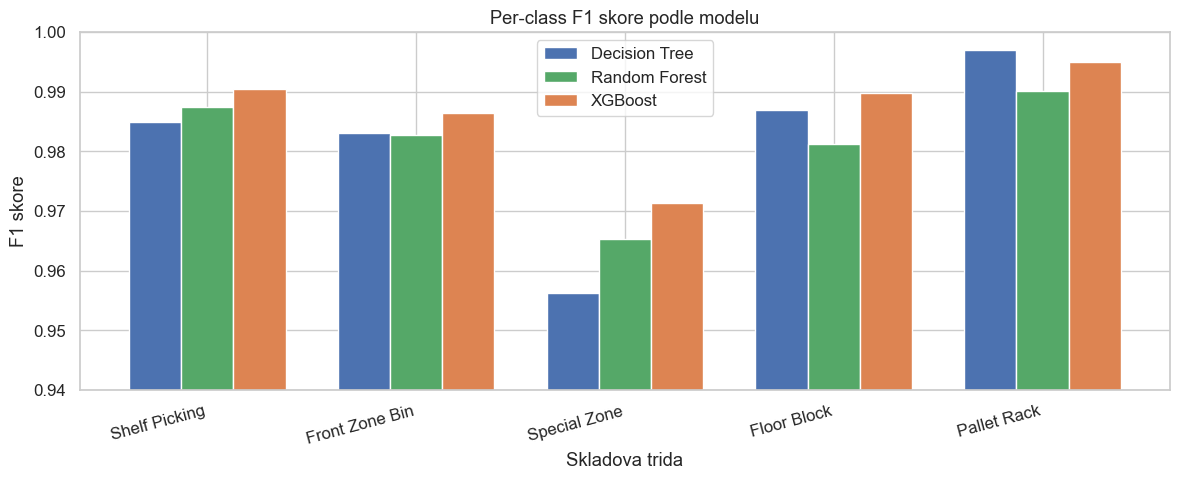

Ulozeno: results/modeling_per_class_f1.png


In [4]:
class_cols = [c for c in comparison.columns if c.startswith("f1_") and c != "f1_macro"]
class_names = [c.replace("f1_", "").replace("_", " ").title() for c in class_cols]

ml_only = comparison[comparison["model"] != "baseline"].copy()
model_labels = {"dt": "Decision Tree", "rf": "Random Forest", "xgb": "XGBoost"}
model_colors = {"dt": "#4C72B0", "rf": "#55A868", "xgb": "#DD8452"}

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(ml_only.iterrows()):
    model_key = row["model"]
    values = [row[c] for c in class_cols]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=model_labels[model_key],
                  color=model_colors[model_key], edgecolor="white")

ax.set_xlabel("Skladova trida")
ax.set_ylabel("F1 skore")
ax.set_title("Per-class F1 skore podle modelu")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, ha="right")
ax.set_ylim(0.94, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "modeling_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/modeling_per_class_f1.png")

## 2. Matice zamen

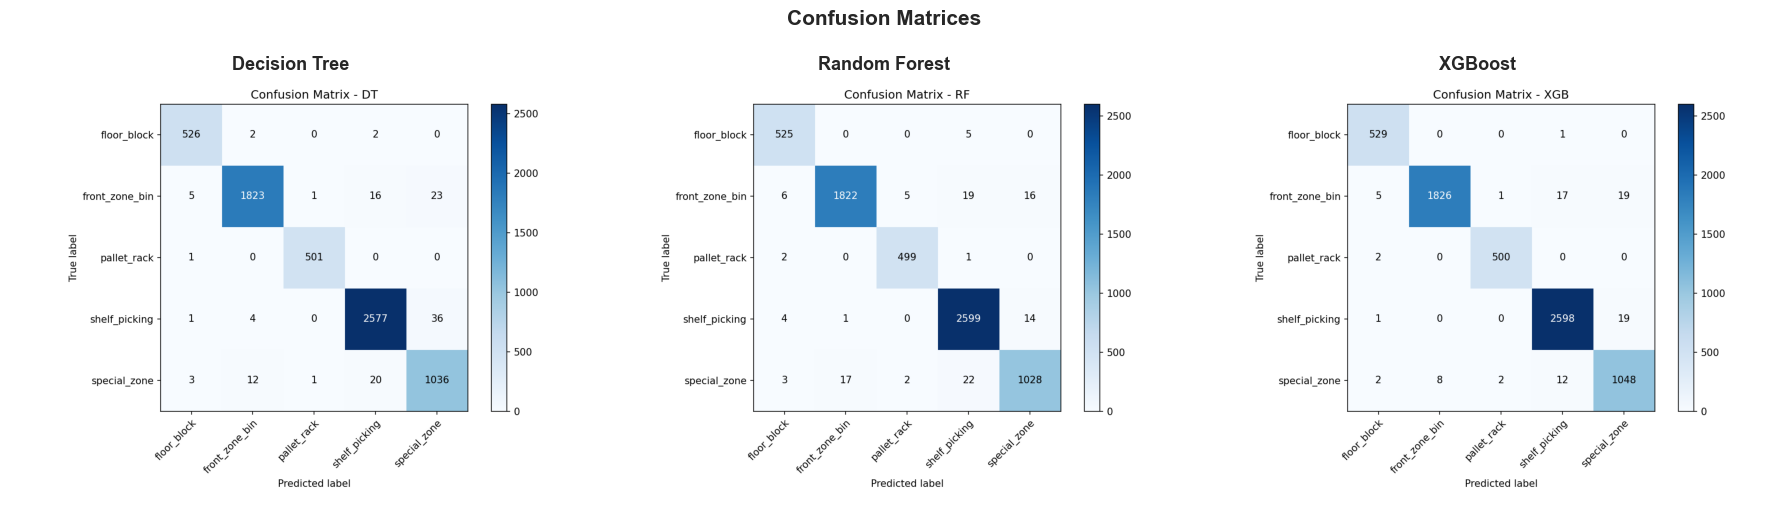

Ulozeno: results/modeling_confusion_matrices.png


In [5]:
cm_files = [
    ("Decision Tree", RESULTS_DIR / "confusion_matrix_dt.png"),
    ("Random Forest", RESULTS_DIR / "confusion_matrix_rf.png"),
    ("XGBoost", RESULTS_DIR / "confusion_matrix_xgb.png"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, path) in zip(axes, cm_files):
    img = mpimg.imread(str(path))
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "modeling_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/modeling_confusion_matrices.png")

## 3. Feature importance

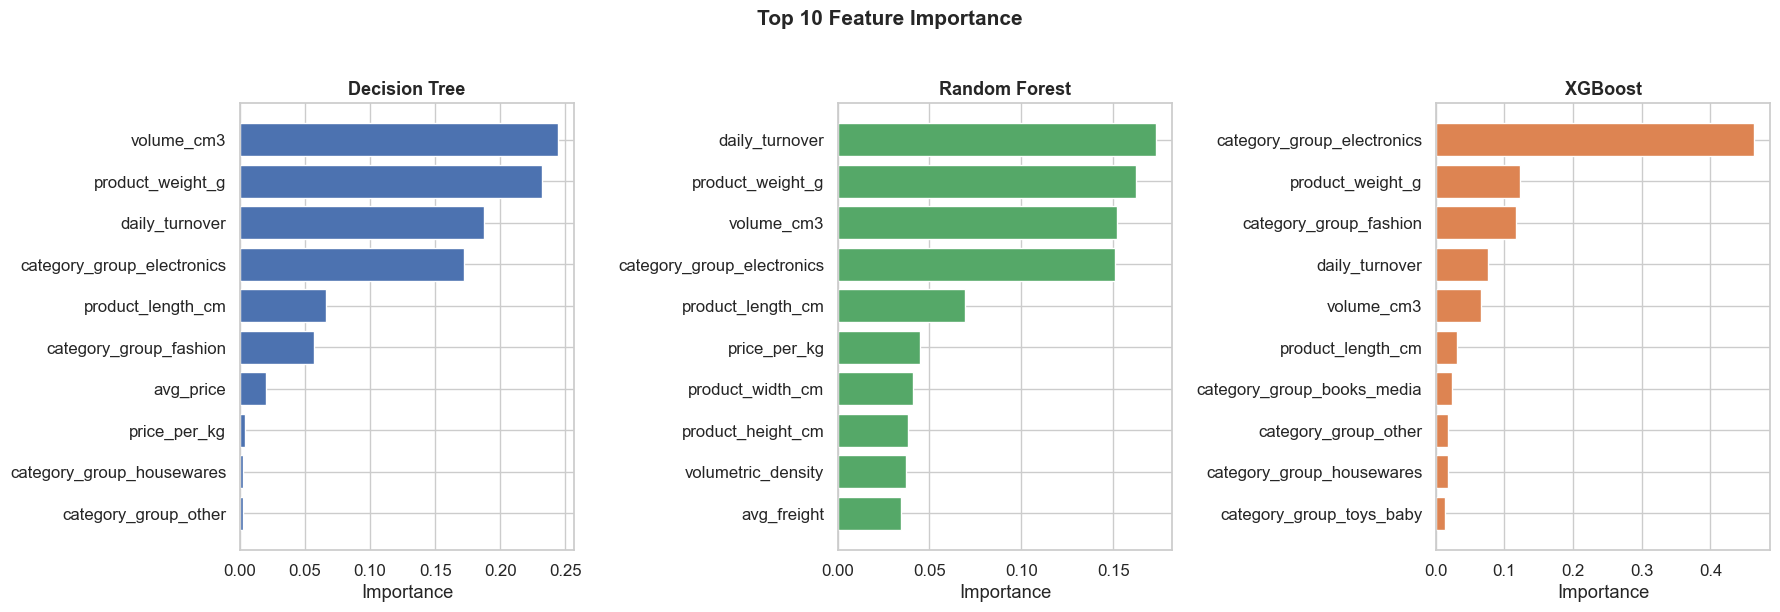

Ulozeno: results/modeling_feature_importance.png


In [6]:
fi_files = {
    "Decision Tree": RESULTS_DIR / "feature_importance_dt.csv",
    "Random Forest": RESULTS_DIR / "feature_importance_rf.csv",
    "XGBoost": RESULTS_DIR / "feature_importance_xgb.csv",
}
fi_colors = {"Decision Tree": "#4C72B0", "Random Forest": "#55A868", "XGBoost": "#DD8452"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (model_name, path) in zip(axes, fi_files.items()):
    fi = pd.read_csv(path).nlargest(10, "importance").sort_values("importance", ascending=True)
    ax.barh(fi["feature"], fi["importance"], color=fi_colors[model_name], edgecolor="white")
    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance")

plt.suptitle("Top 10 Feature Importance", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "modeling_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/modeling_feature_importance.png")

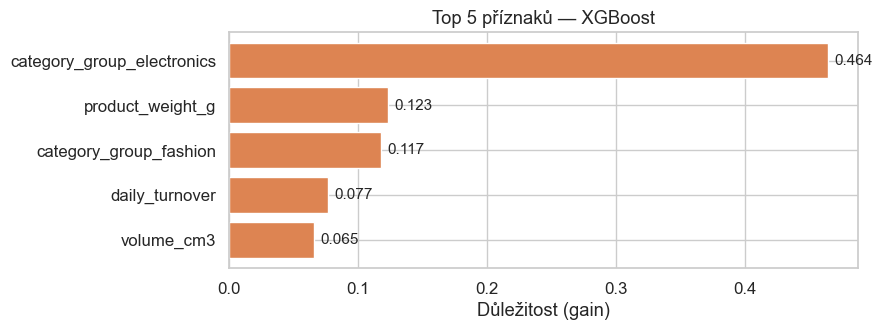

In [7]:
fi_xgb = pd.read_csv(RESULTS_DIR / "feature_importance_xgb.csv").nlargest(5, "importance")
fi_xgb = fi_xgb.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(fi_xgb["feature"], fi_xgb["importance"], color="#DD8452", edgecolor="white")
for bar, val in zip(bars, fi_xgb["importance"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=11)
ax.set_xlabel("Důležitost (gain)")
ax.set_title("Top 5 příznaků — XGBoost")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "modeling_top5_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Casova slozitost

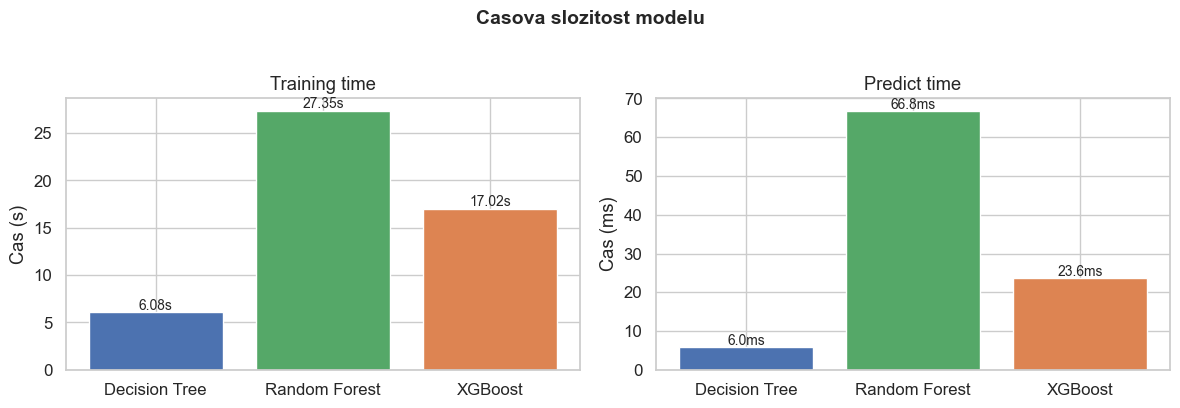

Ulozeno: results/modeling_timing.png


In [8]:
timing = comparison[comparison["model"] != "baseline"].copy()
timing["model_label"] = timing["model"].map({"dt": "Decision Tree", "rf": "Random Forest", "xgb": "XGBoost"})
timing_colors = [model_colors[m] for m in timing["model"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Train time
ax1.bar(timing["model_label"], timing["train_time_s"], color=timing_colors, edgecolor="white")
for i, val in enumerate(timing["train_time_s"]):
    ax1.text(i, val + 0.3, f"{val:.2f}s", ha="center", fontsize=10)
ax1.set_ylabel("Cas (s)")
ax1.set_title("Training time")

# Predict time
ax2.bar(timing["model_label"], timing["predict_time_ms"], color=timing_colors, edgecolor="white")
for i, val in enumerate(timing["predict_time_ms"]):
    ax2.text(i, val + 0.5, f"{val:.1f}ms", ha="center", fontsize=10)
ax2.set_ylabel("Cas (ms)")
ax2.set_title("Predict time")

plt.suptitle("Casova slozitost modelu", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "modeling_timing.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/modeling_timing.png")

## 5. Shrnuti

In [9]:
print("SHRNUTI FAZE 5: Trenovani modelu")
print("=" * 60)
print(comparison.to_string(index=False))
print(f"\nNejlepsi model: XGBoost (ulozeno jako models/best_model.joblib)")

SHRNUTI FAZE 5: Trenovani modelu
   model  accuracy  f1_macro  f1_shelf_picking  f1_front_zone_bin  f1_special_zone  f1_floor_block  f1_pallet_rack  train_time_s  predict_time_ms
      dt    0.9807    0.9816            0.9849             0.9830           0.9562          0.9869          0.9970          6.08             5.98
      rf    0.9822    0.9814            0.9875             0.9827           0.9653          0.9813          0.9901         27.35            66.85
     xgb    0.9865    0.9866            0.9905             0.9865           0.9713          0.9897          0.9950         17.02            23.63
baseline    1.0000    1.0000            1.0000             1.0000           1.0000          1.0000          1.0000          0.00             0.00

Nejlepsi model: XGBoost (ulozeno jako models/best_model.joblib)
